# Notebook entregable para el reclutamiento de Data Acquisition de UNAM Motorsport

En esta segunda etapa de trabajo, he dado una estructura un poco más rigida a la notebook, con el objetivo de tener más orden

In [8]:
#Requesitos de la NB
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

In [9]:
# 1. Cargamos el dataset 
df = pd.read_csv('data.csv')

# 2. Visualizamos las primeras 5 filas para entender la estructura de los datos
print("--- Primeras 5 filas del dataset ---")
display(df.head())

# 3. Revisar información general: nombres de columnas, tipos de datos y conteo de nulos
print("\n--- Información del dataset ---")
df.info()

--- Primeras 5 filas del dataset ---


,Timestamp,speed_kmph,accel_x,accel_y,brake_pressure,steering_angle,throttle,lane_deviation,phone_usage,headway_distance,reaction_time,behavior_label
0,0.00,36.075011,0.535763,0.708633,23.107812,-3.169956,53.123505,0.851871,1,17.996005,1.400050,Distracted
1,0.01,38.090536,0.973764,0.044312,36.961137,-24.380082,36.383904,1.459495,1,29.904182,1.428537,Distracted
2,0.02,71.314445,1.000000,0.789375,79.734087,-6.100238,78.110507,0.254723,0,11.126012,0.406950,Aggressive
3,0.03,86.485997,1.000000,0.221966,45.007002,17.886191,82.794935,0.911664,0,11.064505,0.539964,Aggressive
4,0.04,52.816777,-0.201763,0.560619,38.759612,-4.104323,61.432375,1.591244,1,21.967570,1.369908,Distracted



--- Información del dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Timestamp         30000 non-null  float64
 1   speed_kmph        30000 non-null  float64
 2   accel_x           30000 non-null  float64
 3   accel_y           30000 non-null  float64
 4   brake_pressure    30000 non-null  float64
 5   steering_angle    30000 non-null  float64
 6   throttle          30000 non-null  float64
 7   lane_deviation    30000 non-null  float64
 8   phone_usage       30000 non-null  int64  
 9   headway_distance  30000 non-null  float64
 10  reaction_time     30000 non-null  float64
 11  behavior_label    30000 non-null  object 
dtypes: float64(10), int64(1), object(1)
memory usage: 2.7+ MB


Nos quedamos solo con lo que necesitamos

In [10]:
# 1. Definir solo las columnas críticas para el análisis dinámico y de seguridad
columnas_utiles = ['Timestamp', 'accel_x', 'accel_y', 'brake_pressure', 'throttle']

# 2. Cargar el dataset optimizando la memoria
print("--- CARGANDO TELEMETRÍA ---")
df_filtrado = df.loc[:, columnas_utiles]

# 3. Validar la huella de memoria
df_filtrado.info()

--- CARGANDO TELEMETRÍA ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Timestamp       30000 non-null  float64
 1   accel_x         30000 non-null  float64
 2   accel_y         30000 non-null  float64
 3   brake_pressure  30000 non-null  float64
 4   throttle        30000 non-null  float64
dtypes: float64(5)
memory usage: 1.1 MB


In [11]:
print("--- INICIANDO DIAGNÓSTICO DE DATOS CRUDOS (MÉTODO DINÁMICO) ---\n")

# ==========================================
# 1. SATURACIÓN DE SEÑAL (Límites Dinámicos)
# ==========================================
# El código investiga cuáles son las cotas superiores e inferiores reales
max_x, min_x = df['accel_x'].max(), df['accel_x'].min()
max_y, min_y = df['accel_y'].max(), df['accel_y'].min()

# Contamos cuántas muestras chocan contra esos límites exactos 
# (usamos una tolerancia de 1e-4 por cómo Python maneja los decimales flotantes)
sat_x = df[(df['accel_x'] >= max_x - 1e-4) | (df['accel_x'] <= min_x + 1e-4)]
sat_y = df[(df['accel_y'] >= max_y - 1e-4) | (df['accel_y'] <= min_y + 1e-4)]

print(f"[1] SATURACIÓN X: Límites detectados [{min_x:.4f}G, {max_x:.4f}G] -> {len(sat_x)} muestras saturadas.")
print(f"[1] SATURACIÓN Y: Límites detectados [{min_y:.4f}G, {max_y:.4f}G] -> {len(sat_y)} muestras saturadas.\n")


# ==========================================
# 2. PÉRDIDAS DE SEÑAL (Saltos en el Timestamp)
# ==========================================
df_filtrado['delta_t'] = df_filtrado['Timestamp'].diff()
saltos_reloj = df_filtrado[abs(df_filtrado['delta_t'] - 0.01) > 0.0001]

if saltos_reloj.empty:
    print("[2] RELOJ: Muestreo continuo a 100 Hz. No hay saltos de tiempo.\n")
else:
    print(f"[2] RELOJ: ¡Alerta! {len(saltos_reloj)} saltos de tiempo detectados.\n")


# ==========================================
# 3. SEÑALES CONGELADAS (Sensores trabados)
# ==========================================
congelados_x = df_filtrado[df_filtrado['accel_x'].diff() == 0.0]
if congelados_x.empty:
    print("[3] CONGELAMIENTO: La señal inercial fluye correctamente.\n")
else:
    print(f"[3] CONGELAMIENTO: Se detectaron {len(congelados_x)} instantes donde la señal X se trabó.\n")


# ==========================================
# 4. FALLAS DE PLAUSIBILIDAD (Umbrales Investigados)
# ==========================================
# Calculamos el rango total de movimiento de cada pedal
rango_freno = df_filtrado['brake_pressure'].max() - df_filtrado['brake_pressure'].min()
rango_acel = df_filtrado['throttle'].max() - df_filtrado['throttle'].min()

# Definimos el "cero" como su valor mínimo real, más un pequeño margen (ej. 5%) por ruido eléctrico
umbral_freno_dinamico = df_filtrado['brake_pressure'].min() + (rango_freno * 0.05)
umbral_acel_dinamico = df_filtrado['throttle'].min() + (rango_acel * 0.05)

df_filtrado['falla_instantanea'] = (df_filtrado['brake_pressure'] > umbral_freno_dinamico) & (df_filtrado['throttle'] > umbral_acel_dinamico)

df_filtrado['grupo_racha'] = (df_filtrado['falla_instantanea'] != df_filtrado['falla_instantanea'].shift()).cumsum()
duracion_rachas = df_filtrado[df_filtrado['falla_instantanea']].groupby('grupo_racha').size()

# Filtramos rachas mayores a 10 muestras (>100 ms)
fallas_confirmadas = duracion_rachas[duracion_rachas > 10].index

if len(fallas_confirmadas) == 0:
    print("[4] PLAUSIBILIDAD: Ningún evento simultáneo superó los 100 ms continuos.")
else:
    print(f"[4] PLAUSIBILIDAD: ¡Se detectaron {len(fallas_confirmadas)} eventos reales (>100ms)!")
    for grupo in fallas_confirmadas:
        evento = df_filtrado[df_filtrado['grupo_racha'] == grupo]
        print(f"    -> Falla en T = {evento['Timestamp'].iloc[0]:.2f} s (Duración: {len(evento) * 10} ms)")

--- INICIANDO DIAGNÓSTICO DE DATOS CRUDOS (MÉTODO DINÁMICO) ---

[1] SATURACIÓN X: Límites detectados [-0.9496G, 1.0000G] -> 12757 muestras saturadas.
[1] SATURACIÓN Y: Límites detectados [-1.5326G, 2.7908G] -> 2 muestras saturadas.

[2] RELOJ: Muestreo continuo a 100 Hz. No hay saltos de tiempo.

[3] CONGELAMIENTO: Se detectaron 5605 instantes donde la señal X se trabó.

[4] PLAUSIBILIDAD: ¡Se detectaron 932 eventos reales (>100ms)!
    -> Falla en T = 0.18 s (Duración: 150 ms)
    -> Falla en T = 0.69 s (Duración: 130 ms)
    -> Falla en T = 1.07 s (Duración: 390 ms)
    -> Falla en T = 1.50 s (Duración: 140 ms)
    -> Falla en T = 1.65 s (Duración: 250 ms)
    -> Falla en T = 1.91 s (Duración: 130 ms)
    -> Falla en T = 2.34 s (Duración: 260 ms)
    -> Falla en T = 2.61 s (Duración: 190 ms)
    -> Falla en T = 2.94 s (Duración: 120 ms)
    -> Falla en T = 3.10 s (Duración: 370 ms)
    -> Falla en T = 3.48 s (Duración: 280 ms)
    -> Falla en T = 3.83 s (Duración: 140 ms)
    -> Fal

En los datos crudos encontramos una cantidad masiva de anomalías, principalmente la saturación del sensor de aceleración en el eje X.

Tendremos que reportarlo e indagar más causas probables, en el lado del evento de plausibilidad en datos crudos aún falta hacer exploración, pero dado a que los datos crudos presentan estas anomalías, aplicaremos el filtrado para obtener más información del sistemas

In [12]:
print("--- APLICANDO ACONDICIONAMIENTO DE SEÑAL ---")

# 1. Configuración del filtro Butterworth Pasa-Bajas
fs = 100.0       # Frecuencia de muestreo (100 Hz)
fc = 5.0         # Frecuencia de corte (5 Hz para dinámica de chasis)
nyq = 0.5 * fs   # Frecuencia de Nyquist (50 Hz)
orden = 4        # Orden del filtro

# 2. Obtener coeficientes
b, a = butter(orden, fc / nyq, btype='low')

# 3. Aplicar filtro filtfilt (fase cero) creando nuevas columnas
df_filtrado['accel_x_filt'] = filtfilt(b, a, df_filtrado['accel_x'])
df_filtrado['accel_y_filt'] = filtfilt(b, a, df_filtrado['accel_y'])

# 4. Calcular la Magnitud del Vector de Fuerza G Combinada
df_filtrado['G_combinada'] = np.sqrt(df_filtrado['accel_x_filt']**2 + df_filtrado['accel_y_filt']**2)

g_max = df_filtrado['G_combinada'].max()
print(f"Fuerza G combinada máxima detectada (señal limpia): {g_max:.4f} G")
print("Nota: Este valor está subestimado debido a la saturación artificial de 1G en el sensor X.")

--- APLICANDO ACONDICIONAMIENTO DE SEÑAL ---
Fuerza G combinada máxima detectada (señal limpia): 1.2720 G
Nota: Este valor está subestimado debido a la saturación artificial de 1G en el sensor X.


In [22]:
print(f"Acelerador - Min: {df_filtrado['throttle'].min():.2f} | Max: {df_filtrado['throttle'].max():.2f} | Mean: {df_filtrado['throttle'].mean():.2f}")
print(f"Freno      - Min: {df_filtrado['brake_pressure'].min():.2f} | Max: {df_filtrado['brake_pressure'].max():.2f} | Mean: {df_filtrado['brake_pressure'].mean():.2f}")

Acelerador - Min: 20.00 | Max: 99.99 | Mean: 55.04
Freno      - Min: 0.00 | Max: 99.99 | Mean: 40.82


--- ANALIZANDO PLAUSIBILIDAD DE PEDALES (APPS vs FRENO) ---
Detectados 29801 datos de Fallo de Plausibilidad.


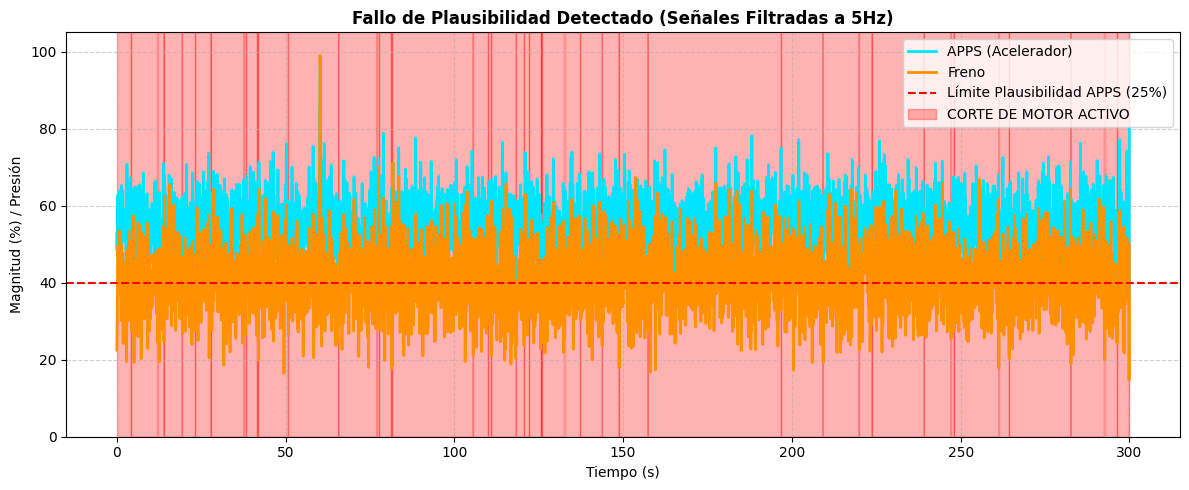

In [ ]:
import matplotlib.pyplot as plt

print("--- ANALIZANDO PLAUSIBILIDAD DE PEDALES (APPS vs FRENO) ---")

# 1. Aplicar el MISMO filtro pasa-bajas a los pedales con los nombres correctos
df_filtrado['apps_filt'] = filtfilt(b, a, df_filtrado['throttle'])
df_filtrado['freno_filt'] = filtfilt(b, a, df_filtrado['brake_pressure'])

# 2. Configurar Umbrales de Seguridad (Ajustados a la calibración del coche)
umbral_apps = 4.0   # Ajustado por el offset del 20% en reposo
umbral_freno = 15.0  # Frenado fuerte

# 3. Detección Vectorizada (El coche se apaga si ambas son True)
df_filtrado['Fallo_Plausibilidad'] = (df_filtrado['freno_filt'] > umbral_freno) & (df_filtrado['apps_filt'] > umbral_apps)

eventos_criticos = df_filtrado[df_filtrado['Fallo_Plausibilidad']]
print(f"Detectados {len(eventos_criticos)} datos de Fallo de Plausibilidad.")

# 4. Gráfica de Evidencia para el Reporte
plt.figure(figsize=(12, 5))

# Graficamos las señales ya filtradas usando 'Timestamp' en el eje X
plt.plot(df_filtrado['Timestamp'], df_filtrado['apps_filt'], label='APPS (Acelerador)', color='#00e5ff', linewidth=2)
plt.plot(df_filtrado['Timestamp'], df_filtrado['freno_filt'], label='Freno', color='#ff9100', linewidth=2)

# Línea del límite del reglamento
plt.axhline(y=umbral_apps, color='red', linestyle='--', label='Límite Plausibilidad APPS (25%)')

# Resaltamos en rojo los momentos exactos del fallo
plt.fill_between(
    df_filtrado['Timestamp'], 
    0, 105, 
    where=df_filtrado['Fallo_Plausibilidad'], 
    color='red', alpha=0.3, label='CORTE DE MOTOR ACTIVO'
)

plt.title('Fallo de Plausibilidad Detectado (Señales Filtradas a 5Hz)', fontweight='bold')
plt.xlabel('Tiempo (s)')
plt.ylabel('Magnitud (%) / Presión')
plt.ylim(0, 105)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Cómo se detectó un offset del pedal, se ajustó la detección del evento de plausibilidad a 40% de activación del pedal y un 15% a la de detección del freno, tomando en cuenta que se considera activación simultanea con más de 20% en aceleración y más de 15% en freno

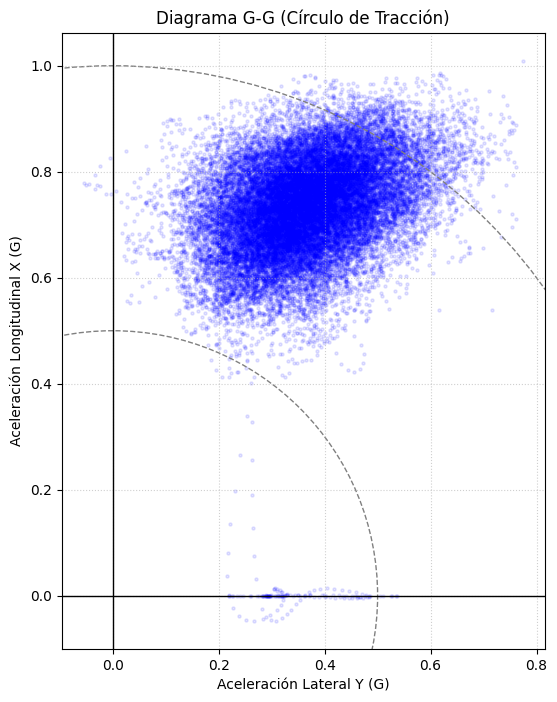

: 

In [ ]:
# Crear el lienzo
plt.figure(figsize=(8, 8))

# Graficar Lateral (Y) en el eje X del plot, y Longitudinal (X) en el eje Y del plot
plt.scatter(df_filtrado['accel_y_filt'], df_filtrado['accel_x_filt'], alpha=0.1, color='blue', s=5)

# Líneas de referencia y diseño
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Círculos de referencia visual (0.5G y 1.0G)
circle1 = plt.Circle((0, 0), 0.5, color='gray', fill=False, linestyle='--')
circle2 = plt.Circle((0, 0), 1.0, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(circle1)
plt.gca().add_artist(circle2)

# Etiquetas
plt.title('Diagrama G-G (Círculo de Tracción)')
plt.xlabel('Aceleración Lateral Y (G)')
plt.ylabel('Aceleración Longitudinal X (G)')

# Bloquear la proporción para que sea un cuadrado perfecto
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle=':', alpha=0.6)

# Mostrar gráfica
plt.show()

Con esto el código de la Notebook termina, la huella tiene características interesantes, el siguiente paso es el análisis de datos, para encontrar causas a los resultados

### CONCLUSIONES

Los datos crudos venían con las siguientes anomalías:
    - Cota superior en aceleración eje X
    - Cota inferior de acelerador mayor a 0, especificamente en 20
    - Cantidad masiva de eventos de plausibilidad (no se encontró explicación más allá de uso incorrecto)

Los gráficos muestran también anomalías de otro tipo, pese a que el máximo de uso de freno si llegaba al 100%, su marca es muy inferior a su rango total de movimiento, es decir del 100% usualmente solo llegaba al 50%

La gráfica G-G muestra un ovalo en lugar de un circulo, que es lo esperado, pero puede tener varias explicaciones, entre ellas el circuito, fallas aerodinámicas o de suspensión, sin embargo al no conocer el trazado, no me aventuro a dar una conclusión más sólida. Por otro lado la misma gráfica muestra datos separados de la figura inicial, lo que en realidad proviene de la ya mencionada cota que se le inyectó al dato de la aceleración en x.



DASHBOARD INTERACTIVO

In [26]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt

print("--- GENERANDO DASHBOARD INTERACTIVO DE TELEMETRÍA ---")

# ====================================================================
# FUNCIÓN DE ACTUALIZACIÓN DEL DASHBOARD
# ====================================================================
def actualizar_dashboard(tiempo_actual):
    """
    Esta función se ejecuta cada vez que mueves el slider.
    Filtra los datos desde el inicio hasta el 'tiempo_actual' y redibuja.
    """
    # Filtramos los datos hasta el tiempo seleccionado en el slider
    df_plot = df_filtrado[df_filtrado['Timestamp'] <= tiempo_actual]

    # Creamos un lienzo con 3 gráficas (1 fila, 3 columnas)
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # ---------------------------------------------------------
    # Gráfica 1: Plausibilidad (Pedales) en el tiempo
    # ---------------------------------------------------------
    axs[0].plot(df_plot['Timestamp'], df_plot['apps_filt'], label='APPS', color='#00e5ff', lw=2)
    axs[0].plot(df_plot['Timestamp'], df_plot['freno_filt'], label='Freno', color='#ff9100', lw=2)
    axs[0].set_title('Telemetría de Pedales (Plausibilidad)', fontweight='bold')
    axs[0].set_xlabel('Tiempo (s)')
    axs[0].set_ylabel('Magnitud (%)')
    # FIJAMOS los ejes basándonos en el total de los datos para que la gráfica no "brinque"
    axs[0].set_xlim(df_filtrado['Timestamp'].min(), df_filtrado['Timestamp'].max())
    axs[0].set_ylim(0, 105)
    axs[0].legend(loc='upper left')
    axs[0].grid(True, linestyle='--', alpha=0.5)

    # ---------------------------------------------------------
    # Gráfica 2: General (Fuerza G Combinada en el tiempo)
    # ---------------------------------------------------------
    axs[1].plot(df_plot['Timestamp'], df_plot['G_combinada'], color='#d50000', lw=2)
    axs[1].set_title('Fuerza G Combinada (Estrés de Chasis)', fontweight='bold')
    axs[1].set_xlabel('Tiempo (s)')
    axs[1].set_ylabel('Fuerza (G)')
    axs[1].set_xlim(df_filtrado['Timestamp'].min(), df_filtrado['Timestamp'].max())
    axs[1].set_ylim(0, df_filtrado['G_combinada'].max() + 0.2)
    axs[1].grid(True, linestyle='--', alpha=0.5)

    # ---------------------------------------------------------
    # Gráfica 3: DIAGRAMA G-G ANIMADO
    # ---------------------------------------------------------
    # Usamos scatter para pintar los puntos como un rastro
    axs[2].scatter(df_plot['accel_y_filt'], df_plot['accel_x_filt'], alpha=0.6, color='purple', s=10)
    
    # Resaltamos el ÚLTIMO punto en rojo para ver dónde está el coche en ese instante exacto
    if not df_plot.empty:
        axs[2].scatter(df_plot['accel_y_filt'].iloc[-1], df_plot['accel_x_filt'].iloc[-1], color='red', s=50, edgecolors='black', zorder=5)

    axs[2].set_title('Diagrama G-G (Desarrollo en Pista)', fontweight='bold')
    axs[2].set_xlabel('Lat G (Curvas)')
    axs[2].set_ylabel('Long G (Freno / Aceleración)')
    
    # Fijamos los ejes para que el "huevo" se dibuje dentro de un cuadro estático
    limite_g = max(abs(df_filtrado['accel_x_filt']).max(), abs(df_filtrado['accel_y_filt']).max()) + 0.2
    axs[2].set_xlim(-limite_g, limite_g)
    axs[2].set_ylim(-limite_g, limite_g)
    
    # Líneas centrales (Cruz de origen)
    axs[2].axhline(0, color='black', lw=1)
    axs[2].axvline(0, color='black', lw=1)
    axs[2].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# ====================================================================
# CREACIÓN DEL SLIDER INTERACTIVO
# ====================================================================
# El slider irá desde el segundo 0 hasta el final de tu telemetría
slider_tiempo = widgets.FloatSlider(
    value=df_filtrado['Timestamp'].min(),
    min=df_filtrado['Timestamp'].min(),
    max=df_filtrado['Timestamp'].max(),
    step=0.2, # Avanza de 0.2 en 0.2 segundos (puedes bajarlo a 0.1 para más fluidez)
    description='Tiempo (s):',
    layout=widgets.Layout(width='90%')
)

# Conectamos el slider con la función de dibujar
salida_interactiva = widgets.interactive(actualizar_dashboard, tiempo_actual=slider_tiempo)
display(salida_interactiva)

--- GENERANDO DASHBOARD INTERACTIVO DE TELEMETRÍA ---


interactive(children=(FloatSlider(value=0.0, description='Tiempo (s):', layout=Layout(width='90%'), max=299.99…